<a href="https://colab.research.google.com/github/utkarshg1/test24/blob/main/Multiclass_classification_with_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiclass classification - weather outlook

In [1]:
from warnings import filterwarnings
filterwarnings("ignore")

# Step 1 - Data Ingestion

In [2]:
url = "https://raw.githubusercontent.com/utkarshg1/Neural-Net-Datasets/refs/heads/main/train_weather.csv"
print(url)

https://raw.githubusercontent.com/utkarshg1/Neural-Net-Datasets/refs/heads/main/train_weather.csv


In [4]:
import pandas as pd
df = pd.read_csv(url)
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


# Target Feature - Weather Type

# Step 2 - Perfom basic data quality checks

In [5]:
df.shape

(13200, 11)

In [6]:
df.isna().sum()

,0
Temperature,0
Humidity,0
Wind Speed,0
Precipitation (%),0
Cloud Cover,0
Atmospheric Pressure,0
UV Index,0
Season,0
Visibility (km),0
Location,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


# Step 3 - Seperate X and Y

In [9]:
X = df.drop(columns = ["Weather Type"])
Y = df["Weather Type"]

In [10]:
X.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain


In [11]:
Y.head()

,Weather Type
0,Rainy
1,Cloudy
2,Sunny
3,Sunny
4,Rainy


In [12]:
Y.value_counts()

,count
Weather Type,
Rainy,3300
Cloudy,3300
Sunny,3300
Snowy,3300


# Step 4 - Apply Train test split

In [13]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [15]:
xtrain.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location
3958,32.0,66,6.0,92.0,partly cloudy,1010.21,2,Spring,1.5,inland
2239,15.0,96,11.0,57.0,overcast,1016.98,0,Autumn,4.0,mountain
3608,28.0,58,6.5,11.0,clear,1025.37,10,Summer,9.0,inland
6848,47.0,84,44.5,85.0,overcast,992.26,2,Winter,2.0,coastal
6119,18.0,66,14.0,10.0,partly cloudy,1000.04,1,Autumn,8.0,coastal


In [16]:
ytrain.head()

,Weather Type
3958,Rainy
2239,Rainy
3608,Sunny
6848,Rainy
6119,Cloudy


In [17]:
xtest.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location
4111,23.0,38,4.5,6.0,clear,1021.19,9,Autumn,10.0,inland
10607,62.0,94,14.5,83.0,clear,1025.57,10,Summer,4.0,inland
7372,40.0,51,2.0,12.0,partly cloudy,1025.15,8,Spring,8.0,mountain
11786,-7.0,79,6.5,90.0,overcast,993.56,0,Winter,1.5,inland
12227,21.0,94,10.0,109.0,partly cloudy,1027.71,11,Spring,9.0,mountain


In [18]:
ytest.head()

,Weather Type
4111,Sunny
10607,Sunny
7372,Sunny
11786,Snowy
12227,Sunny


In [19]:
xtrain.shape

(10560, 10)

In [20]:
xtest.shape

(2640, 10)

# Step 5 - Apply preprocessing on X, Y

In [21]:
X.dtypes

,0
Temperature,float64
Humidity,int64
Wind Speed,float64
Precipitation (%),float64
Cloud Cover,object
Atmospheric Pressure,float64
UV Index,int64
Season,object
Visibility (km),float64
Location,object


In [22]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
cat_cols

['Cloud Cover', 'Season', 'Location']

In [23]:
num_cols = X.select_dtypes(include="number").columns.tolist()
num_cols

['Temperature',
 'Humidity',
 'Wind Speed',
 'Precipitation (%)',
 'Atmospheric Pressure',
 'UV Index',
 'Visibility (km)']

In [24]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [25]:
num_pipe = make_pipeline(
    SimpleImputer(strategy = "median"),
    StandardScaler()
)

In [26]:
cat_pipe = make_pipeline(
    SimpleImputer(strategy = "most_frequent"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")
)

In [28]:
pre = ColumnTransformer(
    [
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ]
).set_output(transform="pandas")

In [29]:
pre.fit(xtrain)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['Temperature', 'Humidity', 'Wind Speed',
                                  'Precipitation (%)', 'Atmospheric Pressure',
                                  'UV Index', 'Visibility (km)']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Cloud Cover', 'Season', 'Location'])])

In [30]:
xtrain_pre = pre.transform(xtrain)
xtrain_pre.head()

,num__Temperature,num__Humidity,num__Wind Speed,num__Precipitation (%),num__Atmospheric Pressure,num__UV Index,num__Visibility (km),cat__Cloud Cover_cloudy,cat__Cloud Cover_overcast,cat__Cloud Cover_partly cloudy,cat__Season_Spring,cat__Season_Summer,cat__Season_Winter,cat__Location_inland,cat__Location_mountain
3958,0.727984,-0.129706,-0.553679,1.204747,0.123123,-0.523097,-1.179544,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
2239,-0.248339,1.352488,0.170676,0.109053,0.304828,-1.041944,-0.436072,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3608,0.498261,-0.524958,-0.481244,-1.331000,0.530012,1.552291,1.050873,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
6848,1.589447,0.759610,5.023858,0.985608,-0.358649,-0.523097,-1.030850,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
6119,-0.076047,-0.129706,0.605290,-1.362306,-0.149837,-0.782520,0.753484,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [31]:
xtest_pre = pre.transform(xtest)
xtest_pre.head()

,num__Temperature,num__Humidity,num__Wind Speed,num__Precipitation (%),num__Atmospheric Pressure,num__UV Index,num__Visibility (km),cat__Cloud Cover_cloudy,cat__Cloud Cover_overcast,cat__Cloud Cover_partly cloudy,cat__Season_Spring,cat__Season_Summer,cat__Season_Winter,cat__Location_inland,cat__Location_mountain
4111,0.211107,-1.513087,-0.770986,-1.487528,0.417823,1.292867,1.348262,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10607,2.450909,1.253675,0.677725,0.922997,0.535380,1.552291,-0.436072,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
7372,1.187431,-0.870803,-1.133164,-1.299695,0.524108,1.033444,0.753484,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
11786,-1.511817,0.512578,-0.481244,1.142136,-0.323758,-1.041944,-1.179544,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
12227,0.096246,1.253675,0.025805,1.736940,0.592817,1.811714,1.050873,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


# Y - OneHotEncoding

In [32]:
ytrain_pre = pd.get_dummies(ytrain, dtype=int)
ytrain_pre.head()

,Cloudy,Rainy,Snowy,Sunny
3958,0,1,0,0
2239,0,1,0,0
3608,0,0,0,1
6848,0,1,0,0
6119,1,0,0,0


In [33]:
ytest_pre = pd.get_dummies(ytest, dtype=int)
ytest_pre.head()

,Cloudy,Rainy,Snowy,Sunny
4111,0,0,0,1
10607,0,0,0,1
7372,0,0,0,1
11786,0,0,1,0
12227,0,0,0,1


# Step 6 - Build neural network
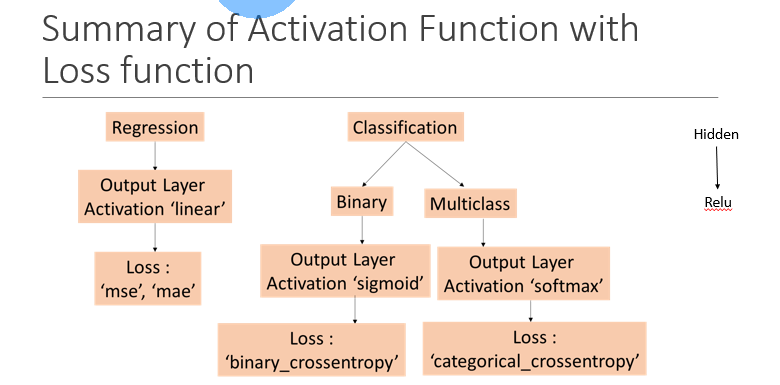

In [34]:
xtrain_pre.shape[1]

15

In [35]:
ytrain_pre.shape[1]

4

# L2 - Ridge penalty is applied on square of coefficients

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

In [37]:
model = Sequential(
    layers = [
        Input(shape=(xtrain_pre.shape[1],)),
        Dense(32, activation="relu", kernel_regularizer=l2(0.01)),
        Dropout(0.2),
        Dense(16, activation="relu", kernel_regularizer=l2(0.01)),
        Dropout(0.2),
        Dense(ytrain_pre.shape[1], activation="softmax")
    ]
)

In [38]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,108 (4.33 KB)

 Trainable params: 1,108 (4.33 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [40]:
es = EarlyStopping(patience=10, restore_best_weights=True)

In [41]:
hist = model.fit(
    xtrain_pre, ytrain_pre, validation_split=0.2, epochs=100, callbacks=[es]
)

Epoch 1/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5416 - loss: 1.4101 - val_accuracy: 0.8674 - val_loss: 0.7960
Epoch 2/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8140 - loss: 0.8604 - val_accuracy: 0.8755 - val_loss: 0.6317
Epoch 3/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8435 - loss: 0.7117 - val_accuracy: 0.8864 - val_loss: 0.5556
Epoch 4/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8619 - loss: 0.6202 - val_accuracy: 0.8939 - val_loss: 0.5091
Epoch 5/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8563 - loss: 0.5951 - val_accuracy: 0.8925 - val_loss: 0.4783
Epoch 6/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8613 - loss: 0.5597 - val_accuracy: 0.9001 - val_loss: 0.4595
Epoch 7/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8767 - loss: 0.5356 - val_accuracy: 0.8968 - val_loss: 0.4467
Epoch 8/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8748 - loss: 0.5241 - val_accu

# Plot the lerarning curve

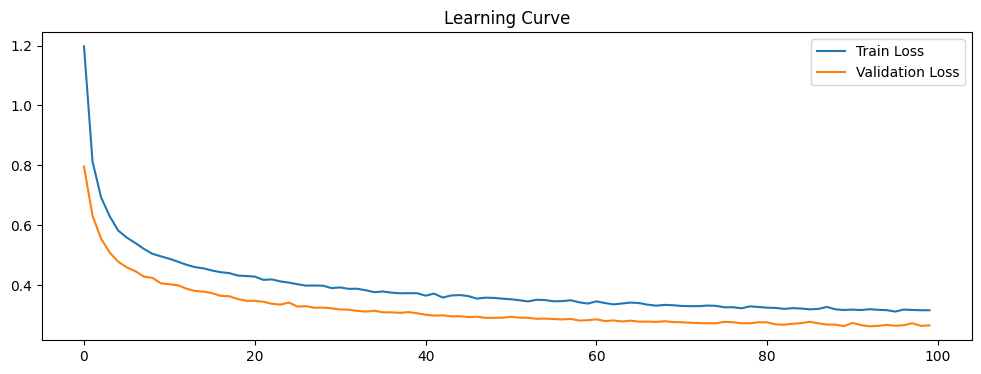

In [42]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.plot(hist.history["loss"], label="Train Loss")
plt.plot(hist.history["val_loss"], label="Validation Loss")
plt.title("Learning Curve")
plt.legend()
plt.show()

# Step 7 - Model evaluation

In [43]:
train_loss, train_acc = model.evaluate(xtrain_pre, ytrain_pre)
print(f"Train Loss : {train_loss:.4f}")
print(f"Train accuracy : {train_acc:.2%}")

330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9103 - loss: 0.2663
Train Loss : 0.2661
Train accuracy : 91.05%


In [45]:
test_loss, test_acc = model.evaluate(xtest_pre, ytest_pre)
print(f"Test loss : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.2%}")

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9080 - loss: 0.2825
Test loss : 0.2821
Test accuracy : 90.45%


In [46]:
classes = ytrain_pre.columns.tolist()
classes

['Cloudy', 'Rainy', 'Snowy', 'Sunny']

In [48]:
yprob_train = model.predict(xtrain_pre)
yprob_train[0:5]

330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[4.0589463e-02, 9.3983352e-01, 5.8400761e-03, 1.3736968e-02],
       [2.1528700e-02, 9.7082359e-01, 6.2320079e-03, 1.4157961e-03],
       [8.6041924e-04, 8.9713772e-05, 1.7521186e-04, 9.9887472e-01],
       [8.7734945e-03, 9.8976177e-01, 9.3082205e-04, 5.3392543e-04],
       [9.9853241e-01, 3.0230719e-04, 2.4897035e-04, 9.1618905e-04]],
      dtype=float32)

In [50]:
train_idx = yprob_train.argmax(axis=1)
train_idx

array([1, 1, 3, ..., 0, 0, 1])

In [51]:
ypred_train = [classes[idx] for idx in train_idx]
ypred_train[0:5]

['Rainy', 'Rainy', 'Sunny', 'Rainy', 'Cloudy']

In [52]:
def predict_weather(model, x):
  yprob = model.predict(x)
  index = yprob.argmax(axis=1)
  ypred = [classes[i] for i in index]
  return ypred

In [53]:
yprob_test = model.predict(xtest_pre)
yprob_test[0:5]

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[7.0546666e-04, 6.6728731e-05, 1.5732957e-04, 9.9907053e-01],
       [4.6320753e-03, 8.3054794e-04, 8.3944463e-04, 9.9369788e-01],
       [9.4529502e-03, 1.9098477e-03, 1.9075343e-03, 9.8672974e-01],
       [2.4178775e-05, 3.6153218e-04, 9.9957663e-01, 3.7655958e-05],
       [1.9381951e-01, 8.1692204e-02, 7.0632763e-02, 6.5385556e-01]],
      dtype=float32)

In [54]:
ytest_pred = predict_weather(model, xtest_pre)
ytest_pred[0:5]

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


['Sunny', 'Sunny', 'Sunny', 'Snowy', 'Sunny']

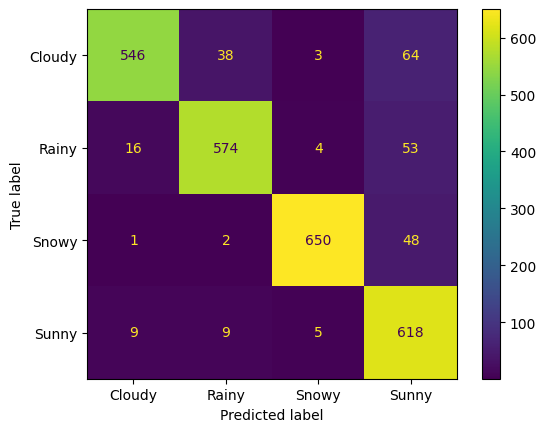

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(ytest, ytest_pred)

In [57]:
from sklearn.metrics import classification_report

print(classification_report(ytest, ytest_pred))

              precision    recall  f1-score   support

      Cloudy       0.95      0.84      0.89       651
       Rainy       0.92      0.89      0.90       647
       Snowy       0.98      0.93      0.95       701
       Sunny       0.79      0.96      0.87       641

    accuracy                           0.90      2640
   macro avg       0.91      0.90      0.90      2640
weighted avg       0.91      0.90      0.91      2640



# Above results show that this is a good model and can be used for out of sample prediction

# Step 8 - Out of sample prediction

In [59]:
url2 = "https://raw.githubusercontent.com/utkarshg1/Neural-Net-Datasets/refs/heads/main/test_weather.csv"
print(url2)

https://raw.githubusercontent.com/utkarshg1/Neural-Net-Datasets/refs/heads/main/test_weather.csv


In [60]:
xnew = pd.read_csv(url2)
xnew.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location
0,0,68,16.0,66.0,overcast,984.94,0,Winter,2.0,mountain
1,107,107,15.0,83.0,partly cloudy,1015.00,11,Summer,7.0,mountain
2,19,76,12.5,35.0,partly cloudy,1017.26,4,Summer,8.0,inland
3,22,99,18.5,NaN,partly cloudy,1012.70,0,NaN,3.5,inland
4,33,25,8.0,6.0,partly cloudy,1023.77,6,Spring,NaN,inland


In [61]:
xnew.isna().sum()

,0
Temperature,0
Humidity,0
Wind Speed,0
Precipitation (%),1
Cloud Cover,1
Atmospheric Pressure,0
UV Index,0
Season,2
Visibility (km),1
Location,2


In [62]:
pre

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['Temperature', 'Humidity', 'Wind Speed',
                                  'Precipitation (%)', 'Atmospheric Pressure',
                                  'UV Index', 'Visibility (km)']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Cloud Cover', 'Season', 'Location'])])

In [63]:
xnew_pre = pre.transform(xnew)
xnew_pre.head()

,num__Temperature,num__Humidity,num__Wind Speed,num__Precipitation (%),num__Atmospheric Pressure,num__UV Index,num__Visibility (km),cat__Cloud Cover_cloudy,cat__Cloud Cover_overcast,cat__Cloud Cover_partly cloudy,cat__Season_Spring,cat__Season_Summer,cat__Season_Winter,cat__Location_inland,cat__Location_mountain
0,-1.109801,-0.030893,0.895032,0.390803,-0.555116,-1.041944,-1.030850,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,5.035295,1.895959,0.750161,0.922997,0.251685,1.811714,0.456095,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,-0.018616,0.364359,0.387983,-0.579668,0.312343,-0.004250,0.753484,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,0.153676,1.500707,1.257209,0.140359,0.189954,-1.041944,-0.584766,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
4,0.785415,-2.155371,-0.263937,-1.487528,0.487069,0.514597,-0.138683,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [64]:
probs = model.predict(xnew_pre)
probs[0:5]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


array([[2.14964253e-04, 2.61177728e-03, 9.96961415e-01, 2.11821345e-04],
       [4.80190851e-02, 1.05219735e-02, 1.56772428e-03, 9.39891338e-01],
       [9.70564544e-01, 1.11838039e-02, 2.62396154e-03, 1.56276803e-02],
       [1.95636582e-02, 9.73196685e-01, 5.39053325e-03, 1.84920570e-03],
       [6.57314202e-03, 9.77569143e-04, 1.17868325e-03, 9.91270542e-01]],
      dtype=float32)

In [65]:
preds = predict_weather(model, xnew_pre)
preds[0:5]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


['Snowy', 'Sunny', 'Cloudy', 'Rainy', 'Sunny']

In [66]:
xnew["Weather_pred"] = preds
xnew[classes] = probs.round(4)

In [67]:
xnew

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather_pred,Cloudy,Rainy,Snowy,Sunny
0,0,68,16.0,66.0,overcast,984.94,0,Winter,2.0,mountain,Snowy,0.0002,0.0026,0.9970,0.0002
1,107,107,15.0,83.0,partly cloudy,1015.00,11,Summer,7.0,mountain,Sunny,0.0480,0.0105,0.0016,0.9399
2,19,76,12.5,35.0,partly cloudy,1017.26,4,Summer,8.0,inland,Cloudy,0.9706,0.0112,0.0026,0.0156
3,22,99,18.5,NaN,partly cloudy,1012.70,0,NaN,3.5,inland,Rainy,0.0196,0.9732,0.0054,0.0018
4,33,25,8.0,6.0,partly cloudy,1023.77,6,Spring,NaN,inland,Sunny,0.0066,0.0010,0.0012,0.9913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,27,59,9.5,41.0,overcast,1001.39,4,Spring,8.0,mountain,Cloudy,0.9857,0.0086,0.0013,0.0045
96,73,82,47.0,107.0,overcast,1002.73,0,Winter,0.5,mountain,Rainy,0.0037,0.9958,0.0002,0.0002
97,2,60,3.0,70.0,overcast,994.19,0,Winter,2.0,mountain,Snowy,0.0008,0.0064,0.9922,0.0007
98,33,44,1.5,11.0,clear,1011.95,7,Summer,8.5,inland,Sunny,0.0007,0.0001,0.0001,0.9991


In [68]:
xnew.to_csv("weather_res.csv")

# Step 9 - Save preprocessor and model

In [69]:
import joblib
joblib.dump(pre, "pre.joblib")

['pre.joblib']

In [70]:
model.save("weather_model.keras")

# Load the model object

In [71]:
p = joblib.load("pre.joblib")
p

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['Temperature', 'Humidity', 'Wind Speed',
                                  'Precipitation (%)', 'Atmospheric Pressure',
                                  'UV Index', 'Visibility (km)']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Cloud Cover', 'Season', 'Location'])])

In [72]:
from keras.models import load_model

m = load_model("weather_model.keras")
m.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,326 (13.00 KB)

 Trainable params: 1,108 (4.33 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,218 (8.67 KB)